# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('/Users/shariqueh/Downloads/data-viz-class-material-master/data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [3]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


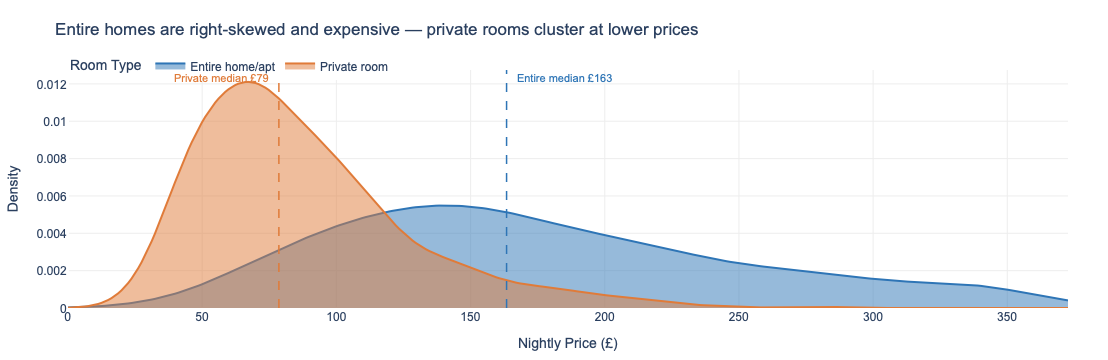

In [13]:
from scipy.stats import gaussian_kde
entire  = df_two.loc[df_two['room_type'] == 'Entire home/apt']['price']
private = df_two.loc[df_two['room_type'] == 'Private room']['price']
x_range = np.linspace(0, df_two['price'].max(), 300)

kde_entire  = gaussian_kde(entire)(x_range)
kde_private = gaussian_kde(private)(x_range)


df_kde = pd.DataFrame({
    'price':     np.tile(x_range, 2),
    'density':   np.concatenate([kde_entire, kde_private]),
    'room_type': ['Entire home/apt'] * 300 + ['Private room'] * 300,
})
fig = px.line(
    data_frame=df_kde,
    x='price',
    y='density',
    color='room_type',
    color_discrete_map=palette,
    labels={'price': 'Nightly Price (£)', 'density': 'Density', 'room_type': 'Room Type'},
    title='Entire homes are right-skewed and expensive — private rooms cluster at lower prices',
)

fig.update_traces(fill='tozeroy', opacity=0.4)

# Median reference lines
fig.add_vline(
    x=med_entire, line_dash='dash', line_color='#2E75B6', line_width=1.5,
    annotation=dict(
        text=f'Entire median £{med_entire:.0f}',
        font=dict(color='#2E75B6', size=11),
        xanchor='left', yanchor='top', xshift=8,
    ),
)

fig.add_vline(
    x=med_private, line_dash='dash', line_color='#E07B39', line_width=1.5,
    annotation=dict(
        text=f'Private median £{med_private:.0f}',
        font=dict(color='#E07B39', size=11),
        xanchor='right', yanchor='top', xshift=-8,
    ),
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    legend=dict(title='Room Type', orientation='h', y=1.08),
    margin=dict(l=60, r=40, t=70, b=40),
)

fig.update_xaxes(gridcolor='#EEEEEE')
fig.update_yaxes(gridcolor='#EEEEEE')

fig.show()


## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

Two cheapest neighbourhoods: ['Lambeth', 'Tower Hamlets']


/var/folders/gc/9_r8msw140sclzqsz8k6cd7r0000gn/T/ipykernel_23990/584557429.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



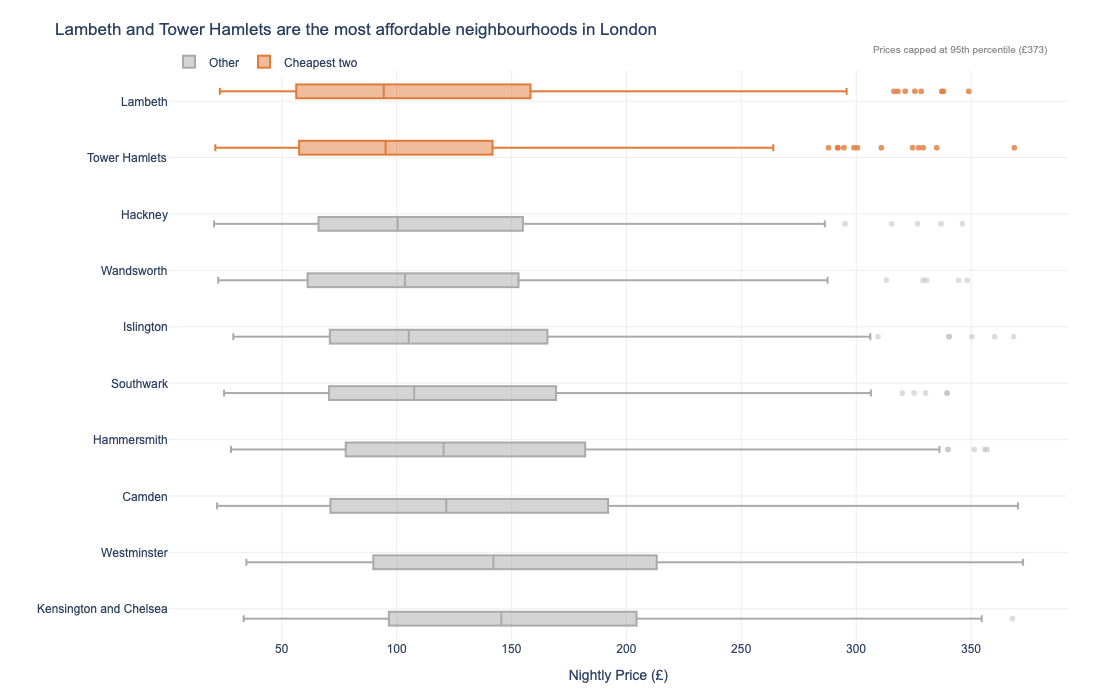

In [14]:
neighbourhood_order = df_cap.groupby('neighbourhood')['price'].median().sort_values(ascending=True).index.tolist()
two_cheapest = neighbourhood_order[:2]
print(f"Two cheapest neighbourhoods: {two_cheapest}")
df_cap['highlight'] = df_cap['neighbourhood'].apply(lambda n: 'Cheapest two' if n in two_cheapest else 'Other')
palette = {'Cheapest two': '#E07B39', 'Other': '#AAAAAA'}
fig = px.box(
    df_cap,
    x='price',
    y='neighbourhood',
    color='highlight',
    category_orders={
        'neighbourhood': neighbourhood_order,   # sorted by median
        'highlight': ['Other', 'Cheapest two'], # legend order
    },
    color_discrete_map=palette,
    labels={'price': 'Nightly Price (£)', 'neighbourhood': ''},
    title=f'{two_cheapest[0]} and {two_cheapest[1]} are the most affordable neighbourhoods in London',
    points='outliers',# show outliers as individual points
    height=700

)

fig.update_traces(
    selector=dict(name='Other'),
    marker=dict(opacity=0.4),
)
fig.update_traces(
    selector=dict(name='Cheapest two'),
    marker=dict(opacity=0.8),
)
fig.add_annotation(
    xref='paper', yref='paper', x=0.98, y=1.05,
    text=f'Prices capped at 95th percentile (£{p95:.0f})',
    showarrow=False,
    font=dict(size=10, color='#888888'),
    align='right',
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    legend=dict(title='', orientation='h', y=1.04),
    margin=dict(l=160, r=40, t=70, b=60),
)
fig.update_xaxes(gridcolor='#EEEEEE')
fig.update_yaxes(gridcolor='#EEEEEE')

fig.show()

In [12]:
df_kde

,price,density,room_type
0,0.000000,2.866883e-05,Entire home/apt
1,1.246187,3.310490e-05,Entire home/apt
2,2.492375,3.810129e-05,Entire home/apt
3,3.738562,4.370974e-05,Entire home/apt
4,4.984749,4.998441e-05,Entire home/apt
...,...,...,...
595,367.625251,2.600676e-22,Private room
596,368.871438,8.496726e-23,Private room
597,370.117625,2.733768e-23,Private room
598,371.363813,8.661959e-24,Private room
